In [1]:
import numpy as np
import matplotlib.pyplot as plt
import successor_features_latest as sf
from tqdm import tqdm

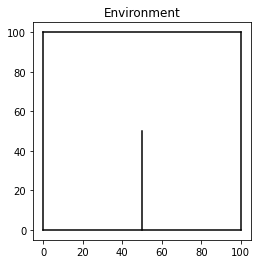

In [2]:
# Initialise an environment
env = sf.Environment('barrier')
env.plot_environment()

In [3]:
# Generate some BVCs given that environment
# NB: probably want  to save and load these for time sake 
bvcs = sf.generate_bvcs(env)

  0%|          | 0/10000 [00:00<?, ?it/s]

Building BVC rate maps


/Users/elisa/Desktop/project/RL/successor_features_latest.py:369: RuntimeWarning: divide by zero encountered in double_scalars
  proportion_along_wall = (position_to_wall_start[0]*bearing[1] - position_to_wall_start[1]*bearing[0])/bearing_cross_product
/Users/elisa/Desktop/project/RL/successor_features_latest.py:370: RuntimeWarning: divide by zero encountered in double_scalars
  proportion_along_bearing = (position_to_wall_start[0]*wall_bearing[1] - position_to_wall_start[1]*wall_bearing[0])/bearing_cross_product
100%|██████████| 256/256 [00:00<00:00, 329.85it/s]


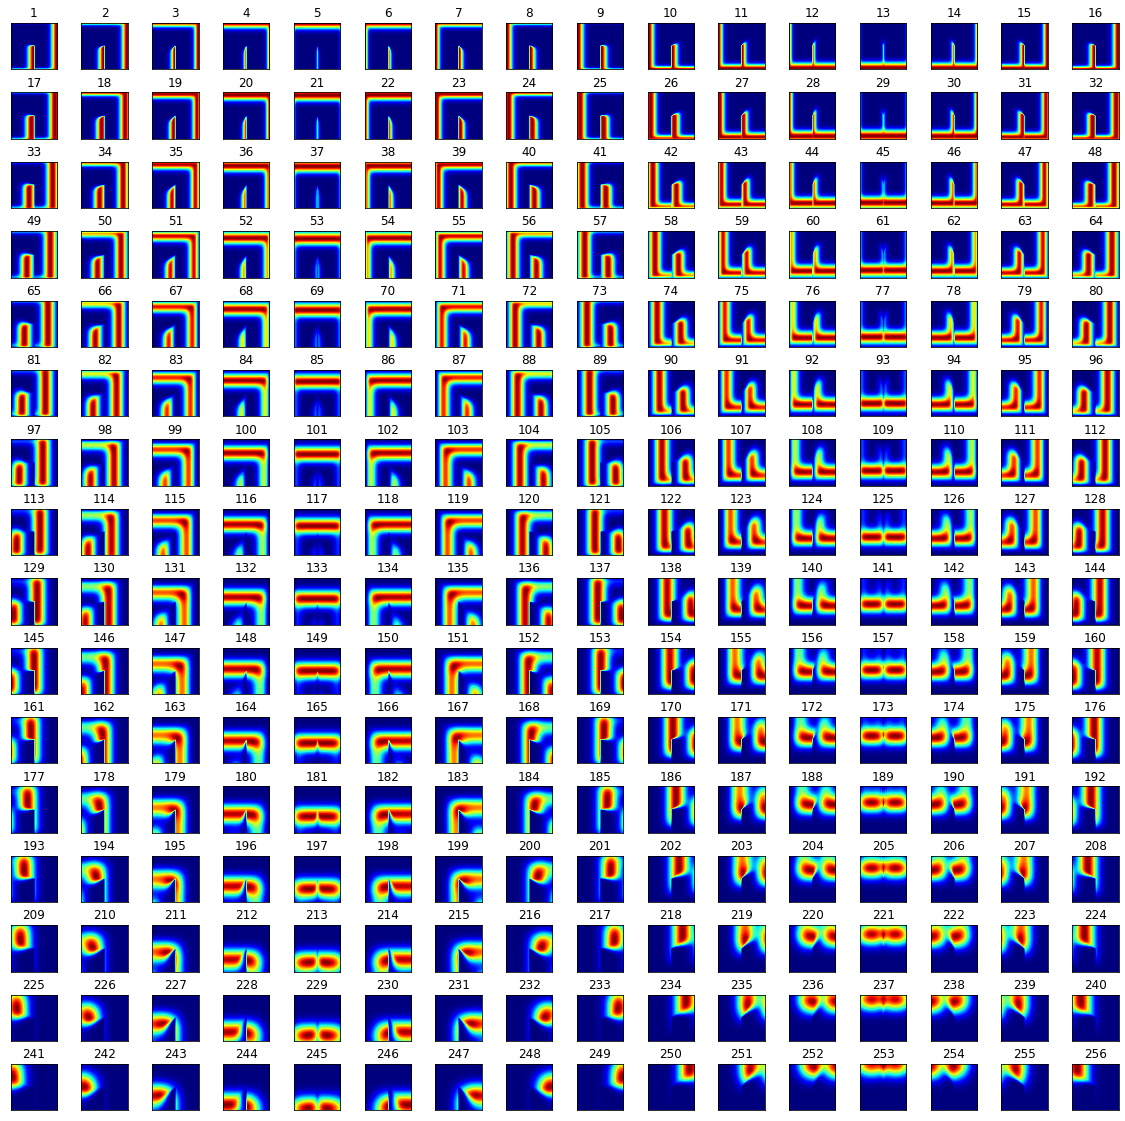

In [4]:
# What do the bvcs look like
sf.plot_cells(bvcs)

  0%|          | 47/10000 [00:00<00:24, 412.41it/s]

Generating transition matrix...


100%|██████████| 10000/10000 [00:11<00:00, 866.35it/s]


Generating SR matrix...


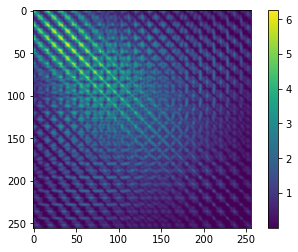

In [5]:
# Fix gamma
gamma = 0.9
# Generate the bin-wise SR
env.generate_sr(gamma=gamma)
# create row vectors for bin-wise firing of each basis feature
bvc_state_rates = np.zeros((len(bvcs),env.map.size))
for i in range(len(bvcs)):
    bvc_state_rates[i] = np.reshape(np.flipud(bvcs[i].rate_map),(1,-1))
# Combine to calculate the feature-based SR (given transition policy in env.T)
M_bvc = bvc_state_rates @ env.M @ bvc_state_rates.T
# Plot feature-based SR matrix
plt.imshow(M_bvc)
plt.colorbar()

 11%|█         | 28/256 [00:00<00:01, 139.56it/s]


Calculating successor features


100%|██████████| 256/256 [00:01<00:00, 155.41it/s]


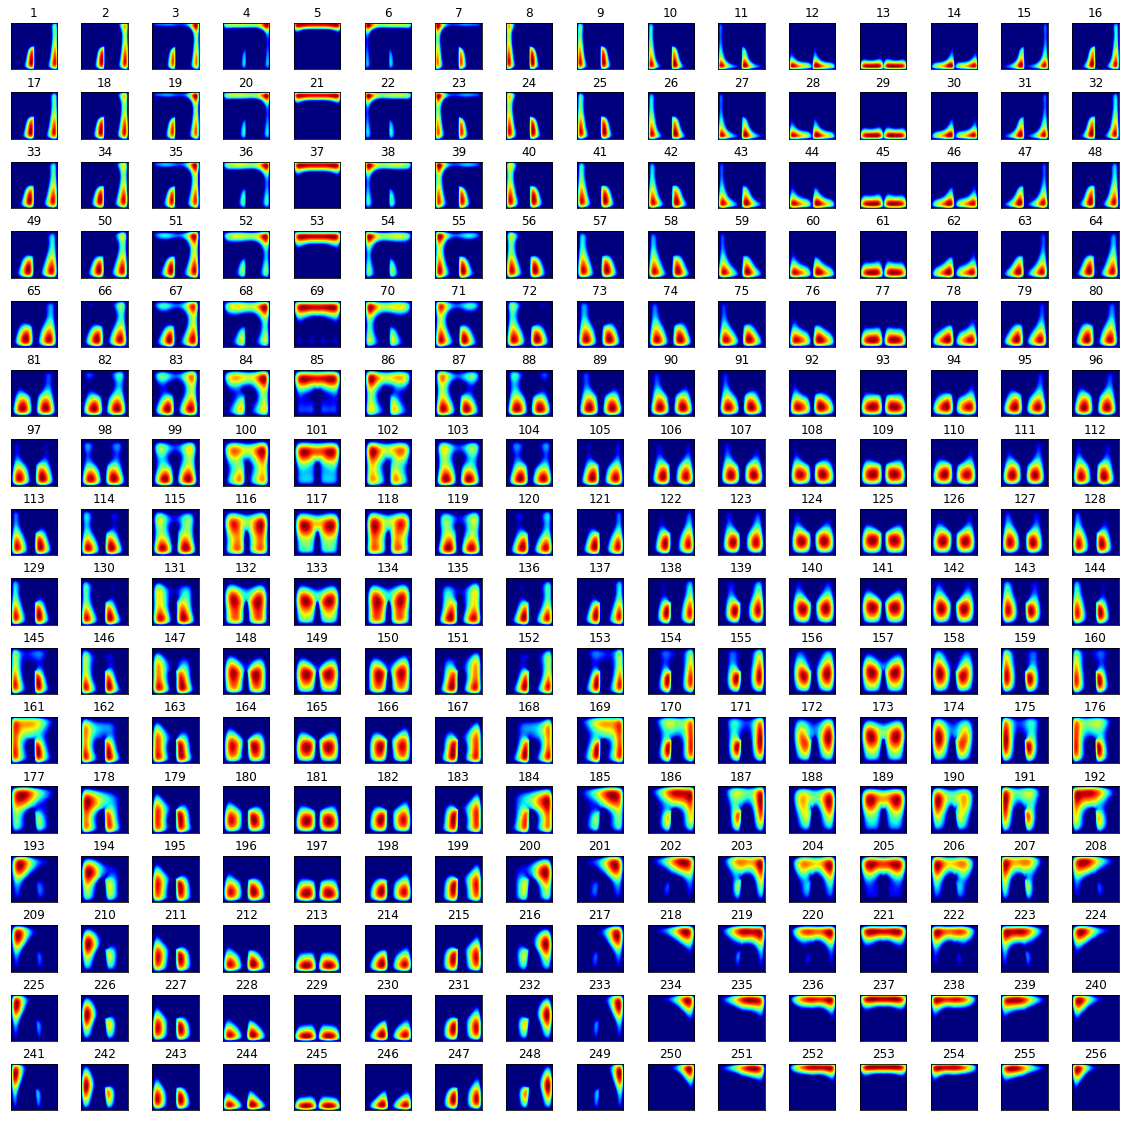

In [6]:
# Also generate the eigenvectors of the successor matrix
successor_features = sf.calculate_successor_features(bvcs,M_bvc)
# See what they look like too
sf.plot_cells(successor_features)

# Activate next two cells to apply rate remapping to the four room environment

In [ ]:
#silencing for four room environment
#picks the highest firing peak from the four sub-environments and set firing in the other three to silenced level (choose appropriately values from 0 to 1)
for i in np.arange(16*16):
    LL=successor_features[i].rate_map[50:,:50]
    LR=successor_features[i].rate_map[50:,50:]
    UL=successor_features[i].rate_map[:50,:50]
    UR=successor_features[i].rate_map[:50,50:]
    vec=[np.mean(LL),np.mean(LR),np.mean(UL),np.mean(UR)]
    choice=np.nanargmax(vec)
    print(choice)
    if choice ==0:
        successor_features[i].rate_map[50:,50:]=0.25*successor_features[i].rate_map[50:,50:]
        successor_features[i].rate_map[:50,:50]=0.25*successor_features[i].rate_map[:50,:50]
        successor_features[i].rate_map[:50,50:]=0.25*successor_features[i].rate_map[:50,50:]
    if choice ==1:
        successor_features[i].rate_map[50:,:50]=0.25*successor_features[i].rate_map[50:,:50]
        successor_features[i].rate_map[:50,:50]=0.25*successor_features[i].rate_map[:50,:50]
        successor_features[i].rate_map[:50,50:]=0.25*successor_features[i].rate_map[:50,50:]
    if choice ==2:
        successor_features[i].rate_map[50:,50:]=0.25*successor_features[i].rate_map[50:,50:]
        successor_features[i].rate_map[50:,:50]=0.25*successor_features[i].rate_map[50:,:50]
        successor_features[i].rate_map[:50,50:]=0.25*successor_features[i].rate_map[:50,50:]
    if choice ==3:
        successor_features[i].rate_map[50:,50:]=0.25*successor_features[i].rate_map[50:,50:]
        successor_features[i].rate_map[50:,:50]=0.25*successor_features[i].rate_map[50:,:50]
        successor_features[i].rate_map[:50,:50]=0.25*successor_features[i].rate_map[:50,:50]

In [ ]:
#silencing for four room environment for BVC basis feature
#picks the highest firing peak from the four sub-environments and set firing in the other three to threshold (choose appropriately from 0 to 1)
for i in np.arange(16*16):
    LL=bvcs[i].rate_map[50:,:50]
    LR=bvcs[i].rate_map[50:,50:]
    UL=bvcs[i].rate_map[:50,:50]
    UR=bvcs[i].rate_map[:50,50:]
    vec=[np.max(LL),np.max(LR),np.max(UL),np.max(UR)]
    choice=np.nanargmax(vec)
    if choice==0:
        bvcs[i].rate_map[50:,50:]=0.25*bvcs[i].rate_map[50:,:50]
        bvcs[i].rate_map[:50,:50]=0.25*bvcs[i].rate_map[:50,:50]
        bvcs[i].rate_map[:50,50:]=0.25*bvcs[i].rate_map[:50,50:]
    if choice ==1:
        bvcs[i].rate_map[50:,:50]=0.25*bvcs[i].rate_map[50:,:50]
        bvcs[i].rate_map[:50,:50]=0.25*bvcs[i].rate_map[:50,:50]
        bvcs[i].rate_map[:50,50:]=0.25*bvcs[i].rate_map[:50,50:]
    if choice ==2:
        bvcs[i].rate_map[50:,50:]=0.25*bvcs[i].rate_map[50:,50:]
        bvcs[i].rate_map[50:,:50]=0.25*bvcs[i].rate_map[50:,:50]
        bvcs[i].rate_map[:50,50:]=0.25*bvcs[i].rate_map[:50,50:]
    if choice ==3:
        bvcs[i].rate_map[50:,50:]=0.25*bvcs[i].rate_map[50:,50:]
        bvcs[i].rate_map[50:,:50]=0.25*bvcs[i].rate_map[50:,:50]
        bvcs[i].rate_map[:50,:50]=0.25*bvcs[i].rate_map[:50,:50]

# Activate next two cells to apply rate remapping to the barrier environment

#somewhere to store our similarities
allnorms=[]

from numpy import linalg as LA
from numpy import random
#if the correlation between sided of the barrier is higher that a certain amount we want to silence the cells
for i in np.arange(16*16):
    LL=successor_features[i].rate_map[50:,:50]
    LR=successor_features[i].rate_map[50:,50:]
    #left=splitit[0]
    #right=splitit[1]
    norm=LA.norm(LL-LR)
    allnorms.append(norm)
for i in np.arange(16*16):
    if allnorms[i]< np.quantile(allnorms,0.50):
        choice = random.choice([1,2])
        if choice==1:
            successor_features[i].rate_map[50:,:50]=0.25*successor_features[i].rate_map[50:,:50]
        elif choice==2: 
            successor_features[i].rate_map[50:,50:]=0.25*successor_features[i].rate_map[50:,50:]

from numpy import linalg as LA
from numpy import random
#somewhere to store our similarities
allnorms=[]

#if the correlation between sided of the barrier is higher that a certain amount we want to silence the cells
for i in np.arange(16*16):
    LL=bvcs[i].rate_map[50:,:50]
    LR=bvcs[i].rate_map[50:,50:]
    norm=LA.norm(LL-LR)
    allnorms.append(norm)
for i in np.arange(16*16):
    #bvcs=prebvcs[i].rate_map
    if allnorms[i]< np.quantile(allnorms,0.50):
        choice= random.choice([1,2])
        if choice==1:
            bvcs[i].rate_map[50:,0:50]=0.25*bvcs[i].rate_map[50:,0:50]
        elif choice ==2: 
            bvcs[i].rate_map[50:,50:100]=0.25*bvcs[i].rate_map[50:,50:100]

Generating SR matrix...


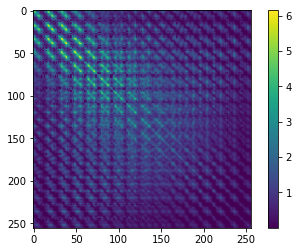

In [9]:
# Fix gamma
gamma = 0.9
# Generate the bin-wise SR
env.generate_sr(gamma=gamma)
# create row vectors for bin-wise firing of each basis feature
bvc_state_rates = np.zeros((len(bvcs),env.map.size))
for i in range(len(bvcs)):
    bvc_state_rates[i] = np.reshape(np.flipud(bvcs[i].rate_map),(1,-1))
# Combine to calculate the feature-based SR (given transition policy in env.T)
M_bvc = bvc_state_rates @ env.M @ bvc_state_rates.T
# Plot feature-based SR matrix
plt.imshow(M_bvc)
plt.colorbar()

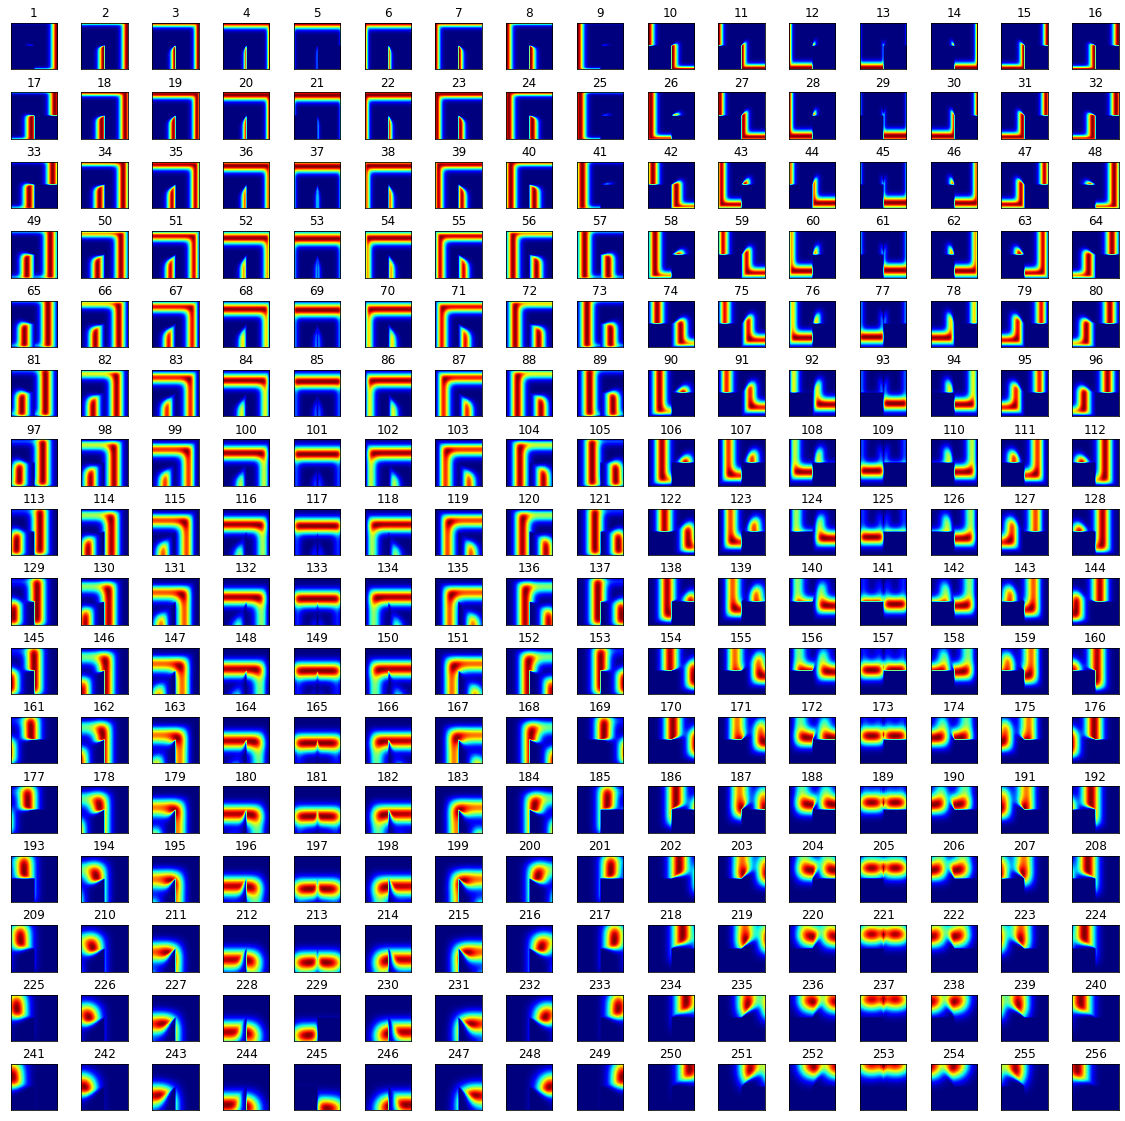

In [10]:
# What do the bvcs look like
sf.plot_cells(bvcs)

In [11]:
# Define the criteria for our goal-directed navigation task
dim_y, dim_x = env.map.shape
goal_location = np.array([75,15])
goal_radius = 10
reward = 1
no_reward = 0
start_locations = np.array([[5,5],[5,95],[95,5],[95,95]])
max_steps = 2000
# Define actions to be movements of a certain distance along a certain bearing 
beta = 80
movement_distance = 2
actions = [movement_distance*np.array([np.cos(x*np.pi),np.sin(x*np.pi)]) for x in np.arange(0,2,0.25)]

In [12]:
# Somewhere to store our trajectory data
bvc_trajectories = []
bvc_success = np.zeros(len(start_locations))
traj_len=[]
# Initialise our reward features
R_bvc = np.zeros(len(bvcs))
# Get our features at the goal location
goal_features = sf.get_firing_rates(int(np.round(goal_location[0]-0.5)), dim_y-1-int(np.round(goal_location[1]-0.5)), bvcs)
eps=0.1
# # Simulate sudden placement at goal location
for action_idx, action in enumerate(actions):
    x,y = goal_location - action
    previous_features = sf.get_firing_rates(int(np.round(x-0.5)), dim_y-1-int(np.round(y-0.5)), bvcs)
    R_bvc = sf.R_update(reward,M_bvc,R_bvc,previous_features,goal_features,gamma=gamma)

# Now go through each start position
for start_i, start_pos in enumerate(start_locations):
    goal_reached = False
    # initialise our trajectory
    x,y = start_pos
    traj = np.empty((0,2))
    traj = np.append(traj,np.array([[x,y]]),axis=0)
    t = 0
    # Loop through actions until goal reached or time runs out
    while not goal_reached:
        # Somewhere to store our similarity metric
        action_values = np.full(len(actions),np.nan)
        # loop through actions
        for action_idx, action in enumerate(actions):
            intersection_points = np.zeros((len(env.walls),2))
            # if the action results in us moving through a wall then we don't want to do that
            for wall_i, wall in enumerate(env.walls):
                wall_start, wall_end = np.array(wall,dtype='float64')
                intersection_points[wall_i] = sf.wall_intersection([x,y],action,wall_start,wall_end)
            # if intersection_points is all nans then we haven't gone through a wall
            if np.all(np.isnan(intersection_points)):
                next_x = x + action[0]
                next_y = y + action[1]
                # Get the features at that new location
                action_features = sf.get_firing_rates(int(np.round(next_x-0.5)), dim_y-1-int(np.round(next_y-0.5)), bvcs)
                action_values[action_idx] = np.dot(R_bvc, M_bvc @ action_features)
        # Now we've looped through all of the actions, we want to choose the best one
        softmax_probs = np.exp(beta*action_values)/np.nansum(np.exp(beta*action_values))
        softmax_probs[np.isnan(action_values)] = 0
        best_action_idx = int(np.random.choice(np.arange(len(action_values)),1,p=softmax_probs))
        # Update our trajectory
        next_x = x + actions[best_action_idx][0]
        next_y = y + actions[best_action_idx][1]
        firing_rates = sf.get_firing_rates(int(np.round(x-0.5)), dim_y-1-int(np.round(y-0.5)), bvcs)
        next_firing_rates = sf.get_firing_rates(int(np.round(next_x-0.5)), dim_y-1-int(np.round(next_y-0.5)), bvcs)
        t += 1
        traj = np.append(traj,np.array([[x,y]]),axis=0)
        if np.sqrt(np.sum((traj[-1]-goal_location)**2)) < goal_radius:
            # Update reward vector and end episiode
            R_bvc = sf.R_update(reward,M_bvc,R_bvc,firing_rates,next_firing_rates,gamma=gamma)
            goal_reached = True
            bvc_trajectories.append(traj)
            bvc_success[start_i] = 1
            traj_len.append(len(traj))
        else:
            x = next_x
            y = next_y
            # Update reward vector 
            R_bvc = sf.R_update(no_reward,M_bvc,R_bvc,firing_rates,next_firing_rates,gamma=gamma)
            if (t >= max_steps):
                bvc_trajectories.append(traj)
                traj_len.append(len(traj))
                break

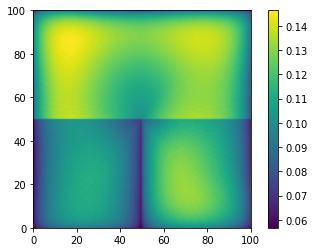

In [13]:
#state value map of the environment
bvc_value_map = np.zeros_like(bvcs[0].rate_map)
for x in range(100):
    for y in range(100):
        rates = sf.get_firing_rates(x,y,bvcs)
        bvc_value_map[y,x] = np.dot(R_bvc,M_bvc @ rates)
plt.imshow(bvc_value_map,extent=[0,100,0,100])
plt.colorbar()
plt.savefig(r'pre_training_BVC_rewards.jpg')

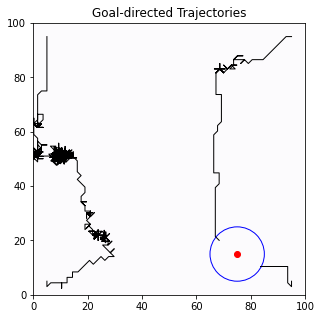

In [15]:
# Plot our trajectories
plt.figure(figsize=(5,5))
for traj in bvc_trajectories:
    plt.plot(traj.T[0], traj.T[1], linewidth=1, c='k')
plt.plot(goal_location[0],goal_location[1], 'ro')
circle2 = plt.Circle((goal_location[0], goal_location[1]), 10, color='b', fill=False)
ax = plt.gca()
ax.add_patch(circle2)
plt.imshow(env.map,cmap="Purples")
plt.xlim([0,100])
plt.ylim([0,100])
plt.savefig(r'pre_training_BVC_trajectories.jpg')
plt.title('Goal-directed BVC Trajectories')
plt.show()

In [16]:
#calculate trail statistics
from scipy import stats
print(np.mean(traj_len))
print(stats.sem(traj_len))
print(np.std(traj_len))

1044.75
552.9738352761367
957.7787779544919


In [17]:
#Iterate travelling to the goal from one of the four starting locations and plot the number of time steps per each
#iteration required to reach the goal
max_steps=2000
# Somewhere to store our trajectory data
bvc_trajectories = []
bvc_success = np.zeros(50)
eps=0.1
# Initialise our reward features
R_bvc = np.zeros(len(bvcs))

# Get our features at the goal location
goal_features = sf.get_firing_rates(int(np.round(goal_location[0]-0.5)), 99-int(np.round(goal_location[1]-0.5)), bvcs)

traj_len=[]
# Simulate sudden placement at goal location
for action_idx, action in enumerate(actions):
    x,y = goal_location - action
    previous_features = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), bvcs)
    R_bvc = sf.R_update(reward,M_bvc,R_bvc,previous_features,goal_features,gamma=gamma) 

start_location= np.array([5,5])
# Now go through each start position
for n in range(50):
#for start_i, start_pos in enumerate(start_locations):
    goal_reached = False
    # initialise our trajectory
    x,y = start_location
    traj = np.empty((0,2))
    traj = np.append(traj,np.array([[x,y]]),axis=0)
    t = 1
    # Loop through actions until goal reached or time runs out
    while not goal_reached:
        # Somewhere to store our similarity metric
        action_values = np.full(len(actions),np.nan)
        # loop through actions
        for action_idx, action in enumerate(actions):
            intersection_points = np.zeros((len(env.walls),2))
            # if the action results in us moving through a wall then we don't want to do that
            for wall_i, wall in enumerate(env.walls):
                wall_start, wall_end = np.array(wall,dtype='float64')
                intersection_points[wall_i] = sf.wall_intersection([x,y],action,wall_start,wall_end)
            # if intersection_points is all nans then we haven't gone through a wall
            if np.all(np.isnan(intersection_points)):
                next_x = x + action[0]
                next_y = y + action[1]
                # Get the features at that new location
                action_features = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), bvcs)
                action_values[action_idx] = np.dot(R_bvc, M_bvc @ action_features)
        # Now we've looped through all of the actions, we want to choose the best one
        softmax_probs = np.exp(beta*action_values)/np.nansum(np.exp(beta*action_values))
        softmax_probs[np.isnan(action_values)] = 0
        best_action_idx = int(np.random.choice(np.arange(len(action_values)),1,p=softmax_probs))
        # Update our trajectory
        next_x = x + actions[best_action_idx][0]
        next_y = y + actions[best_action_idx][1]
        firing_rates = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), bvcs)
        next_firing_rates = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), bvcs)
        t += 1
        traj = np.append(traj,np.array([[x,y]]),axis=0)
        if np.sqrt(np.sum((traj[-1]-goal_location)**2)) < goal_radius:
            # Update reward vector and end episiode
            R_bvc = sf.R_update(reward,M_bvc,R_bvc,firing_rates,next_firing_rates,gamma=gamma)
            goal_reached = True
            bvc_trajectories.append(traj)
            bvc_success[n] = 1
            traj_len.append(len(traj))
        else:
            x = next_x
            y = next_y
            # Update reward vector 
            R_bvc = sf.R_update(no_reward,M_bvc,R_bvc,firing_rates,next_firing_rates,gamma=gamma)
            if (t >= max_steps):
                bvc_trajectories.append(traj)
                traj_len.append(len(traj))
                break

/Users/elisa/Desktop/project/RL/successor_features_latest.py:369: RuntimeWarning: divide by zero encountered in double_scalars
  proportion_along_wall = (position_to_wall_start[0]*bearing[1] - position_to_wall_start[1]*bearing[0])/bearing_cross_product
/Users/elisa/Desktop/project/RL/successor_features_latest.py:370: RuntimeWarning: divide by zero encountered in double_scalars
  proportion_along_bearing = (position_to_wall_start[0]*wall_bearing[1] - position_to_wall_start[1]*wall_bearing[0])/bearing_cross_product


0.0


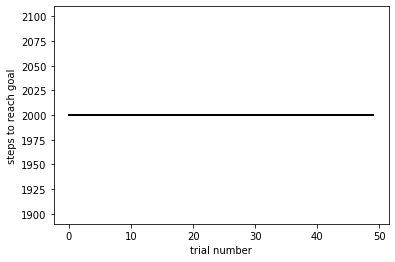

In [18]:
#plot the number of steps to reach the goal for each trial 
trials=[]
for traj in bvc_trajectories:
    trials=np.append(trials,len(traj))

plt.plot(trials, linewidth=2,c='k')
plt.xlabel("trial number")
plt.ylabel("steps to reach goal")
plt.savefig(r'BVC_step_numbers.jpg')
plt.title('Step-number to goal')
print(sum(bvc_success))

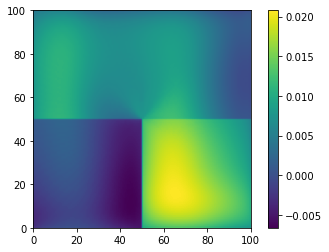

In [19]:
#plot the state value map of the environment
bvc_value_map = np.zeros_like(bvcs[0].rate_map)
for x in range(100):
    for y in range(100):
        rates = sf.get_firing_rates(x,y,bvcs)
        bvc_value_map[y,x] = np.dot(R_bvc,M_bvc @ rates)
plt.imshow(bvc_value_map,extent=[0,100,0,100])
plt.colorbar()
plt.savefig(r'post_training_BVC_rewards.jpg')

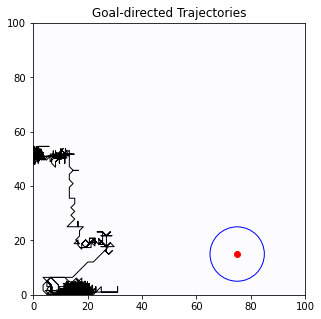

In [20]:
# Plot our trajectories
plt.figure(figsize=(5,5))
for traj in bvc_trajectories:
    plt.plot(traj.T[0], traj.T[1], linewidth=1, c='k')
plt.plot(goal_location[0],goal_location[1], 'ro')
circle2 = plt.Circle((goal_location[0], goal_location[1]), 10, color='b', fill=False)
ax = plt.gca()
ax.add_patch(circle2)
#plt.plot(env.walls[0],env.walls[1])
plt.imshow(env.map,cmap="Purples")
plt.xlim([0,100])
plt.ylim([0,100])
plt.savefig(r'post_training_BVC_trajectories.jpg')
plt.title('Goal-directed BVC Trajectories')
plt.show()

In [21]:
#statistics of the trials including test for normality
from scipy import stats
print(np.mean(traj_len))
print(stats.sem(traj_len))
print(np.std(traj_len))
from scipy.stats import shapiro
stat, p =shapiro(traj_len)
print('stat=%.3f,p=%.3f\n'%(stat,p))
if p>0.05:
    print('Probably Gaussian')
else:
    print('Probably not Gaussian')
    
print(traj_len)

2000.0
0.0
0.0
stat=1.000,p=1.000

Probably Gaussian
[2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000]


/Users/elisa/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/morestats.py:1678: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "


Generating SR matrix...


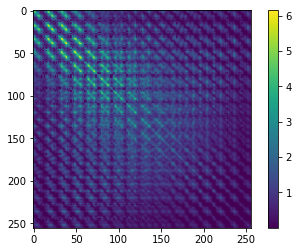

In [22]:
# Fix gamma
gamma = 0.9
# Generate the bin-wise SR
env.generate_sr(gamma=gamma)
# create row vectors for bin-wise firing of each basis feature
bvc_state_rates = np.zeros((len(bvcs),env.map.size))
for i in range(len(bvcs)):
    bvc_state_rates[i] = np.reshape(np.flipud(bvcs[i].rate_map),(1,-1))
# Combine to calculate the feature-based SR (given transition policy in env.T)
M_bvc = bvc_state_rates @ env.M @ bvc_state_rates.T
# Plot feature-based SR matrix
plt.imshow(M_bvc)
plt.colorbar()

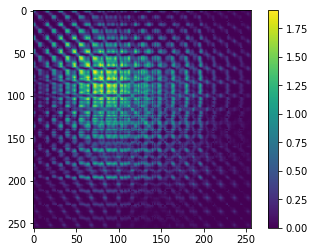

In [23]:
# create row vectors for bin-wise firing of each place cell feature
place_state_rates = np.zeros((len(successor_features),env.map.size))
for i in range(len(successor_features)):
    place_state_rates[i] = np.reshape(np.flipud(successor_features[i].rate_map),(1,-1))
# Combine to calculate the feature-based SR (given transition policy in env.T)
M_place = place_state_rates @ env.M @ place_state_rates.T
# Plot feature-based SR matrix
plt.imshow(M_place)
plt.colorbar()

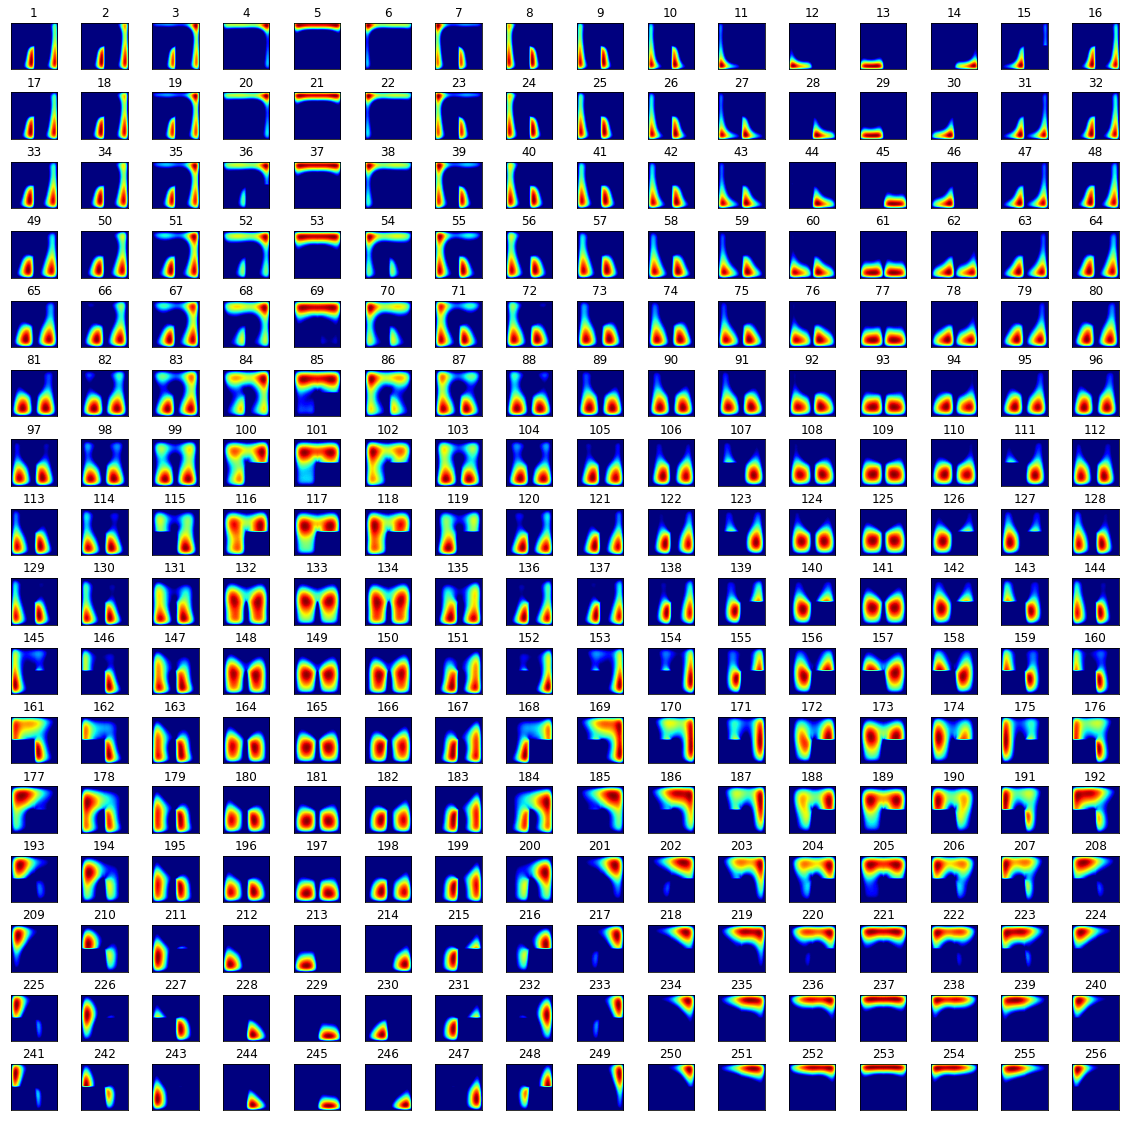

In [24]:
# See what they look like too
sf.plot_cells(successor_features)

In [25]:
# Somewhere to store our trajectory data
place_trajectories = []
place_success = np.zeros(len(start_locations))
# Initialise our reward features
R = np.zeros(len(successor_features))

# Get our features at the goal location
goal_features = sf.get_firing_rates(int(np.round(goal_location[0]-0.5)), 99-int(np.round(goal_location[1]-0.5)), successor_features)
traj_len=[]
# Simulate sudden placement at goal location
for action_idx, action in enumerate(actions):
    x,y = goal_location - action
    previous_features = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), successor_features)
    R = sf.R_update(reward,M_place,R,previous_features,goal_features,gamma=gamma)

# Now go through each start position
for start_i, start_pos in enumerate(start_locations):
    goal_reached = False
    # initialise our trajectory
    x,y = start_pos
    traj = np.empty((0,2))
    traj = np.append(traj,np.array([[x,y]]),axis=0)
    t = 0
    # Loop through actions until goal reached or time runs out
    while not goal_reached:
        # Somewhere to store our similarity metric
        action_values = np.full(len(actions),np.nan)
        # loop through actions
        for action_idx, action in enumerate(actions):
            intersection_points = np.zeros((len(env.walls),2))
            # if the action results in us moving through a wall then we don't want to do that
            for wall_i, wall in enumerate(env.walls):
                wall_start, wall_end = np.array(wall,dtype='float64')
                intersection_points[wall_i] = sf.wall_intersection([x,y],action,wall_start,wall_end)
            # if intersection_points is all nans then we haven't gone through a wall
            if np.all(np.isnan(intersection_points)):
                next_x = x + action[0]
                next_y = y + action[1]
                # Get the features at that new location
                action_features = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), successor_features)
                action_values[action_idx] = np.dot(R, M_place @ action_features)
        # Now we've looped through all of the actions, we want to choose the best one
        softmax_probs = np.exp(beta*action_values)/np.nansum(np.exp(beta*action_values))
        softmax_probs[np.isnan(action_values)] = 0
        best_action_idx = int(np.random.choice(np.arange(len(action_values)),1,p=softmax_probs))
        # Update our trajectory
        next_x = x + actions[best_action_idx][0]
        next_y = y + actions[best_action_idx][1]
        firing_rates = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), successor_features)
        next_firing_rates = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), successor_features)
        t += 1
        traj = np.append(traj,np.array([[x,y]]),axis=0)
        if np.sqrt(np.sum((traj[-1]-goal_location)**2)) < goal_radius:
            # Update reward vector and end episiode
            R = sf.R_update(reward,M_place,R,firing_rates,next_firing_rates,gamma=gamma)
            goal_reached = True
            place_trajectories.append(traj)
            place_success[start_i] = 1
            traj_len.append(len(traj))
        else:
            x = next_x
            y = next_y
            # Update reward vector 
            R = sf.R_update(no_reward,M_place,R,firing_rates,next_firing_rates,gamma=gamma)
            if (t >= max_steps):
                place_trajectories.append(traj)
                traj_len.append(len(traj))
                break

/Users/elisa/Desktop/project/RL/successor_features_latest.py:369: RuntimeWarning: divide by zero encountered in double_scalars
  proportion_along_wall = (position_to_wall_start[0]*bearing[1] - position_to_wall_start[1]*bearing[0])/bearing_cross_product
/Users/elisa/Desktop/project/RL/successor_features_latest.py:370: RuntimeWarning: divide by zero encountered in double_scalars
  proportion_along_bearing = (position_to_wall_start[0]*wall_bearing[1] - position_to_wall_start[1]*wall_bearing[0])/bearing_cross_product


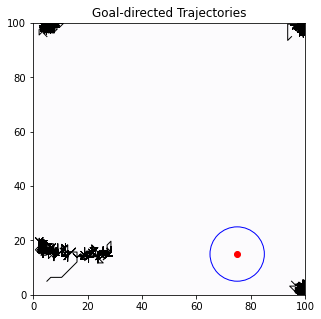

In [27]:
# Plot our trajectories
plt.figure(figsize=(5,5))
for traj in place_trajectories:
    plt.plot(traj.T[0], traj.T[1], linewidth=1, c='k')
plt.plot(goal_location[0],goal_location[1], 'ro')
circle2 = plt.Circle((goal_location[0], goal_location[1]), 10, color='b', fill=False)
ax = plt.gca()
ax.add_patch(circle2)
plt.imshow(env.map,cmap="Purples")
plt.xlim([0,100])
plt.ylim([0,100])
plt.savefig(r'pre-training_canonical_PC_trajectories.jpg')
plt.title('Goal-directed BVC-SR Place cell Trajectories')
plt.show()


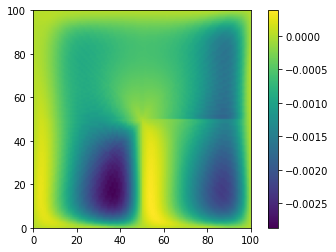

In [28]:
#plot the state-value maps of the environment
place_value_map = np.zeros_like(successor_features[0].rate_map)
for x in range(100):
    for y in range(100):
        rates = sf.get_firing_rates(x,y,successor_features)
        place_value_map[y,x] = np.dot(R,M_place @ rates)
plt.imshow(place_value_map,extent=[0,100,0,100])
plt.colorbar()
plt.savefig(r'pre-training_canonical_PC_rewards.jpg')

In [29]:
#stats on the trial data
from scipy import stats
print(np.mean(traj_len))
print(stats.sem(traj_len))
print(np.std(traj_len))

2001.0
0.0
0.0


In [30]:
#now run for 50 trials
start_location = np.array([5,5])

traj_len=[]
# Somewhere to store our trajectory data
place_trajectories = []
place_success = np.zeros(50)
eps=0.1
# Initialise our reward features
R = np.zeros(len(successor_features))
# Get our features at the goal location
goal_features = sf.get_firing_rates(int(np.round(goal_location[0]-0.5)), 99-int(np.round(goal_location[1]-0.5)), successor_features)

# Simulate sudden placement at goal location
for action_idx, action in enumerate(actions):
    x,y = goal_location - action
    previous_features = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), successor_features)
    R = sf.R_update(reward,M_place,R,previous_features,goal_features,gamma=gamma) #what happened to alpha here?

# Now go through each start position
for n in range(50):
#for start_i, start_pos in enumerate(start_locations):
    goal_reached = False
    # initialise our trajectory
    x,y = start_location
    traj = np.empty((0,2))
    traj = np.append(traj,np.array([[x,y]]),axis=0)
    t = 1
    # Loop through actions until goal reached or time runs out
    while not goal_reached:
        # Somewhere to store our similarity metric
        action_values = np.full(len(actions),np.nan)
        # loop through actions
        for action_idx, action in enumerate(actions):
            intersection_points = np.zeros((len(env.walls),2))
            # if the action results in us moving through a wall then we don't want to do that
            for wall_i, wall in enumerate(env.walls):
                wall_start, wall_end = np.array(wall,dtype='float64')
                intersection_points[wall_i] = sf.wall_intersection([x,y],action,wall_start,wall_end)
            # if intersection_points is all nans then we haven't gone through a wall
            if np.all(np.isnan(intersection_points)):
                next_x = x + action[0]
                next_y = y + action[1]
                # Get the features at that new location
                action_features = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), successor_features)
                action_values[action_idx] = np.dot(R, M_place @ action_features)
        # Now we've looped through all of the actions, we want to choose the best one
        #softmax_probs = np.exp(beta*action_values)/np.nansum(np.exp(beta*action_values))
        #softmax_probs[np.isnan(action_values)] = 0
        #best_action_idx = int(np.random.choice(np.arange(len(action_values)),1,p=softmax_probs))
        p=np.random.random()
        if p<eps:
            best_action_idx=np.random.choice(7)
            while np.isnan(action_values[best_action_idx]):
                best_action_idx = np.random.choice(7)
        else:
            best_action_idx = np.nanargmax(action_values)
        # Update our trajectory
        next_x = x + actions[best_action_idx][0]
        next_y = y + actions[best_action_idx][1]
        firing_rates = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), successor_features)
        next_firing_rates = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), successor_features)
        t += 1
        traj = np.append(traj,np.array([[x,y]]),axis=0)
        if np.sqrt(np.sum((traj[-1]-goal_location)**2)) < goal_radius:
            # Update reward vector and end episiode
            R_ = sf.R_update(reward,M_place,R,firing_rates,next_firing_rates,gamma=gamma)
            goal_reached = True
            place_trajectories.append(traj)
            place_success[n] = 1
            traj_len.append(len(traj))
        else:
            x = next_x
            y = next_y
            # Update reward vector 
            R = sf.R_update(no_reward,M_place,R,firing_rates,next_firing_rates,gamma=gamma)
            if (t >= max_steps):
                place_trajectories.append(traj)
                R = sf.R_update(no_reward,M_place,R,firing_rates,next_firing_rates,gamma=gamma)
                traj_len.append(len(traj))
                break

/Users/elisa/Desktop/project/RL/successor_features_latest.py:369: RuntimeWarning: divide by zero encountered in double_scalars
  proportion_along_wall = (position_to_wall_start[0]*bearing[1] - position_to_wall_start[1]*bearing[0])/bearing_cross_product
/Users/elisa/Desktop/project/RL/successor_features_latest.py:370: RuntimeWarning: divide by zero encountered in double_scalars
  proportion_along_bearing = (position_to_wall_start[0]*wall_bearing[1] - position_to_wall_start[1]*wall_bearing[0])/bearing_cross_product


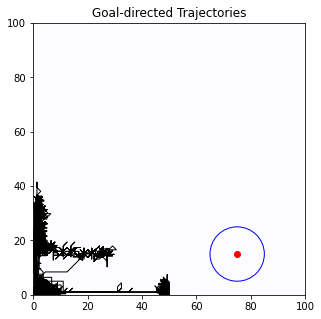

In [31]:
# Plot our trajectories
plt.figure(figsize=(5,5))
for traj in place_trajectories:
    plt.plot(traj.T[0], traj.T[1], linewidth=1, c='k')
plt.plot(goal_location[0],goal_location[1], 'ro')
circle2 = plt.Circle((goal_location[0], goal_location[1]), 10, color='b', fill=False)
ax = plt.gca()
ax.add_patch(circle2)
#plt.plot(env.walls[0],env.walls[1])
plt.imshow(env.map,cmap="Purples")
plt.xlim([0,100])
plt.ylim([0,100])
plt.savefig(r'post_training_canonical_PC_trajectories.jpg')
plt.title('Goal-directed Trajectories')
plt.show()

0.0


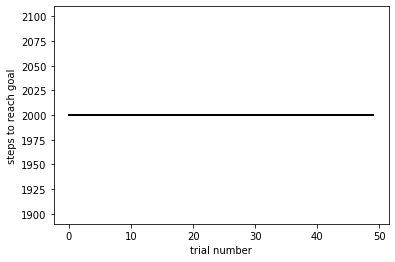

In [32]:
#step number to goal for each trial
trials=[]
for traj in place_trajectories:
    trials=np.append(trials,len(traj))

plt.plot(trials, linewidth=2,c='k')
plt.xlabel("trial number")
plt.ylabel("steps to reach goal")
plt.savefig(r'canonical_PC_step_number.jpg')
print(sum(place_success))

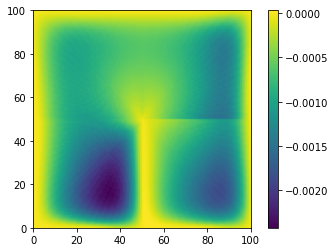

In [33]:
#state-value map of the environment
place_value_map = np.zeros_like(successor_features[0].rate_map)
for x in range(100):
    for y in range(100):
        rates = sf.get_firing_rates(x,y,successor_features)
        place_value_map[y,x] = np.dot(R,M_place @ rates)
plt.imshow(place_value_map,extent=[0,100,0,100])
plt.colorbar()
plt.savefig(r'post_training_canonical_PC_rewards.jpg')

In [34]:
#statistics of the trials including test for normality
from scipy import stats
print(np.mean(traj_len))
print(stats.sem(traj_len))
print(np.std(traj_len))
stat, p =shapiro(traj_len)
print('stat=%.3f,p=%.3f\n'%(stat,p))
if p>0.05:
    print('Probably Gaussian')
else:
    print('Probably not Gaussian')
    
print(traj_len)

2000.0
0.0
0.0
stat=1.000,p=1.000

Probably Gaussian
[2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000]


/Users/elisa/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/morestats.py:1678: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "


In [ ]:
# Generate some place cells
# NB: probably want  to save and load these for time sake 
place_cells = sf.generate_place_cells(env)


  0%|          | 14/10000 [00:00<01:12, 137.01it/s]

Building place cell rate maps


 51%|█████▏    | 5129/10000 [00:59<01:17, 62.63it/s] 

In [ ]:
# See what the place cells look like
sf.plot_cells(place_cells)

In [ ]:
# create row vectors for bin-wise firing of each place cell feature
gauss_place_state_rates = np.zeros((len(place_cells),env.map.size))
for i in range(len(place_cells)):
    gauss_place_state_rates[i] = np.reshape(np.flipud(place_cells[i].rate_map),(1,-1))
# Combine to calculate the feature-based SR (given transition policy in env.T)
M_place = gauss_place_state_rates @ env.M @ gauss_place_state_rates.T
# Plot feature-based SR matrix
plt.imshow(M_place)
plt.colorbar()

In [ ]:
# Somewhere to store our trajectory data
place_trajectories = []
place_success = np.zeros(len(start_locations))
traj_len=[]
# Initialise our reward features
R_place = np.zeros(len(place_cells))

# Get our features at the goal location
goal_features = sf.get_firing_rates(int(np.round(goal_location[0]-0.5)), 99-int(np.round(goal_location[1]-0.5)), place_cells)

# Simulate sudden placement at goal location
for action_idx, action in enumerate(actions):
    x,y = goal_location - action
    previous_features = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), place_cells)
    R_place = sf.R_update(reward,M_place,R_place,previous_features,goal_features,gamma=gamma)

# Now go through each start position
for start_i, start_pos in enumerate(start_locations):
    goal_reached = False
    # initialise our trajectory
    x,y = start_pos
    traj = np.empty((0,2))
    traj = np.append(traj,np.array([[x,y]]),axis=0)
    t = 0
    # Loop through actions until goal reached or time runs out
    while not goal_reached:
        # Somewhere to store our similarity metric
        action_values = np.full(len(actions),np.nan)
        # loop through actions
        for action_idx, action in enumerate(actions):
            intersection_points = np.zeros((len(env.walls),2))
            # if the action results in us moving through a wall then we don't want to do that
            for wall_i, wall in enumerate(env.walls):
                wall_start, wall_end = np.array(wall,dtype='float64')
                intersection_points[wall_i] = sf.wall_intersection([x,y],action,wall_start,wall_end)
            # if intersection_points is all nans then we haven't gone through a wall
            if np.all(np.isnan(intersection_points)):
                next_x = x + action[0]
                next_y = y + action[1]
                # Get the features at that new location
                action_features = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), place_cells)
                action_values[action_idx] = np.dot(R_place, M_place @ action_features)
        # Now we've looped through all of the actions, we want to choose the best one
        softmax_probs = np.exp(beta*action_values)/np.nansum(np.exp(beta*action_values))
        softmax_probs[np.isnan(action_values)] = 0
        best_action_idx = int(np.random.choice(np.arange(len(action_values)),1,p=softmax_probs))
        # Update our trajectory
        next_x = x + actions[best_action_idx][0]
        next_y = y + actions[best_action_idx][1]
        firing_rates = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), place_cells)
        next_firing_rates = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), place_cells)
        t += 1
        traj = np.append(traj,np.array([[x,y]]),axis=0)
        if np.sqrt(np.sum((traj[-1]-goal_location)**2)) < goal_radius:
            # Update reward vector and end episiode
            R_place = sf.R_update(reward,M_place,R_place,firing_rates,next_firing_rates,gamma=gamma)
            goal_reached = True
            place_trajectories.append(traj)
            place_success[start_i] = 1
            traj_len.append(len(traj))
        else:
            x = next_x
            y = next_y
            # Update reward vector 
            R_place = sf.R_update(no_reward,M_place,R_place,firing_rates,next_firing_rates,gamma=gamma)
            if (t >= max_steps):
                place_trajectories.append(traj)
                traj_len.append(len(traj))
                break

In [ ]:
#state-value map of the environment
gauss_place_value_map = np.zeros_like(place_cells[0].rate_map)
for x in range(100):
    for y in range(100):
        rates = sf.get_firing_rates(x,y,place_cells)
        gauss_place_value_map[y,x] = np.dot(R_place,M_place @ rates)
plt.imshow(place_value_map,extent=[0,100,0,100],vmin=-0.05,vmax=0.05)
plt.colorbar()
plt.savefig(r'pre_training_gaussian_PC_rewards.jpg')

In [ ]:
# Plot our trajectories
plt.figure(figsize=(5,5))
for traj in place_trajectories:
    plt.plot(traj.T[0], traj.T[1], linewidth=1, c='k')
plt.xlim([0,100])
plt.ylim([0,100])
plt.title('Goal-directed Place Cell Trajectories')
plt.show()

# Which Trajectories successfully reached the goal
print(place_success)

In [ ]:
# Plot our trajectories
plt.figure(figsize=(5,5))
for traj in place_trajectories:
    plt.plot(traj.T[0], traj.T[1], linewidth=1, c='k')
plt.plot(goal_location[0],goal_location[1], 'ro')
circle2 = plt.Circle((goal_location[0], goal_location[1]), 10, color='b', fill=False)
ax = plt.gca()
ax.add_patch(circle2)
plt.imshow(env.map,cmap="Purples")
plt.xlim([0,100])
plt.ylim([0,100])
plt.savefig(r'pre_training_gaussian_PC_trajectories.jpg')
plt.title('Goal-directed Trajectories Gaussian Place cells')
plt.show()

In [ ]:
#stats on the trial data
from scipy import stats
print(np.mean(traj_len))
print(stats.sem(traj_len))
print(np.std(traj_len))

In [ ]:
# Somewhere to store our trajectory data
place_trajectories = []
place_success = np.zeros(50)
eps=0.1
# Initialise our reward features
R_place = np.zeros(len(place_cells))
# Get our features at the goal location
goal_features = sf.get_firing_rates(int(np.round(goal_location[0]-0.5)), 99-int(np.round(goal_location[1]-0.5)), place_cells)

traj_len=[]
# Simulate sudden placement at goal location
for action_idx, action in enumerate(actions):
    x,y = goal_location - action
    previous_features = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), place_cells)
    R_place= sf.R_update(reward,M_place,R_place,previous_features,goal_features,gamma = gamma) 

start_location= np.array([5,5])
# Now go through each start position
for n in range(50):
#for start_i, start_pos in enumerate(start_locations):    
    goal_reached = False
    # initialise our trajectory
    x,y = start_location
    traj = np.empty((0,2))
    traj = np.append(traj,np.array([[x,y]]),axis=0)
    t = 0
    # Loop through actions until goal reached or time runs out
    while not goal_reached:
        # Somewhere to store our similarity metric
        action_values = np.full(len(actions),np.nan)
        # loop through actions
        for action_idx, action in enumerate(actions):
            intersection_points = np.zeros((len(env.walls),2))
            # if the action results in us moving through a wall then we don't want to do that
            for wall_i, wall in enumerate(env.walls):
                wall_start, wall_end = np.array(wall,dtype='float64')
                intersection_points[wall_i] = sf.wall_intersection([x,y],action,wall_start,wall_end)
            # if intersection_points is all nans then we haven't gone through a wall
            if np.all(np.isnan(intersection_points)):
                next_x = x + action[0]
                next_y = y + action[1]
                # Get the features at that new location
                action_features = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), place_cells)
                action_values[action_idx] = np.dot(R_place, M_place @ action_features)
        # Now we've looped through all of the actions, we want to choose the best one
        #softmax_probs = np.exp(beta*action_values)/np.nansum(np.exp(beta*action_values))
        #softmax_probs[np.isnan(action_values)] = 0
        #best_action_idx = int(np.random.choice(np.arange(len(action_values)),1,p=softmax_probs))
        p=np.random.random()
        if p<eps:
            best_action_idx=np.random.choice(7)
            while np.isnan(action_values[best_action_idx]):
                best_action_idx = np.random.choice(7)
        else:
            best_action_idx = np.nanargmax(action_values)
        # Update our trajectory
        next_x = x + actions[best_action_idx][0]
        next_y = y + actions[best_action_idx][1]
        firing_rates = sf.get_firing_rates(int(np.round(x-0.5)), 99-int(np.round(y-0.5)), place_cells)
        next_firing_rates = sf.get_firing_rates(int(np.round(next_x-0.5)), 99-int(np.round(next_y-0.5)), place_cells)
        t += 1
        traj = np.append(traj,np.array([[x,y]]),axis=0)
        if np.sqrt(np.sum((traj[-1]-goal_location)**2)) < goal_radius:
            # Update reward vector and end episiode
            R_place = sf.R_update(reward,M_place,R_place,firing_rates,next_firing_rates,gamma=gamma)
            goal_reached = True
            place_trajectories.append(traj)
            place_success[n] = 1
            traj_len.append(len(traj))
        else:
            x = next_x
            y = next_y
            # Update reward vector 
            R_place = sf.R_update(no_reward,M_place,R_place,firing_rates,next_firing_rates,gamma=gamma)
            if (t >= max_steps):
                place_trajectories.append(traj)
                traj_len.append(len(traj))
                break

In [ ]:
trials=[]
for traj in place_trajectories:
    trials=np.append(trials,len(traj))
plt.plot(trials, linewidth=2,c='k')
plt.savefig(r'gaussian_PC_step_number.jpg')
plt.xlabel("trial number")
plt.ylabel("steps to reach goal")
print(sum(place_success))

In [ ]:
# Plot our trajectories
plt.figure(figsize=(5,5))
for traj in place_trajectories:
    plt.plot(traj.T[0], traj.T[1], linewidth=1, c='k')
plt.plot(goal_location[0],goal_location[1], 'ro')
circle2 = plt.Circle((goal_location[0], goal_location[1]), 10, color='b', fill=False)
ax = plt.gca()
ax.add_patch(circle2)
#plt.plot(env.walls[0],env.walls[1])
plt.imshow(env.map,cmap="Purples")
plt.xlim([0,100])
plt.ylim([0,100])
plt.savefig(r'post_training_gaussian_PC_trajectories.jpg')
plt.title('Goal-directed Trajectories')
plt.show()
print(sum(place_success))

In [ ]:
#state-value map of the environment
gauss_place_value_map = np.zeros_like(place_cells[0].rate_map)
for x in range(100):
    for y in range(100):
        rates = sf.get_firing_rates(x,y,place_cells)
        gauss_place_value_map[y,x] = np.dot(R_place,M_place @ rates)
plt.imshow(gauss_place_value_map,extent=[0,100,0,100])
plt.colorbar()
plt.savefig(r'post_training_gaussian_PC_rewards.jpg')


In [ ]:
#stats about the trial data
from scipy import stats
print(np.mean(traj_len))
print(stats.sem(traj_len))
print(np.std(traj_len))
print(traj_len)

In [ ]:
#normalised place value maps comparison
fig, (ax1,ax2,ax3) = plt.subplots(1,3)
fig.suptitle('BVC , place cells and gaussian reward maps')
ax1.imshow(bvc_value_map,extent=[0,100,0,100],vmin=-0.5,vmax=1.4)
ax2.imshow(place_value_map,extent=[0,100,0,100],vmin=-0.5,vmax=1.4)
ax3.imshow(gauss_place_value_map,extent=[0,100,0,100],vmin=-0.5,vmax=1.4)
plt.savefig(r'comparison_rewards.jpg')

In [ ]:
#correlation coefficient calculation between each value map and that of gaussian
print(np.corrcoef(bvc_value_map.reshape(1,10000),gauss_place_value_map.reshape(1,10000)))
print(np.corrcoef(place_value_map.reshape(1,10000),gauss_place_value_map.reshape(1,10000)))